# Traning masif_ppi_search NN

### Prerequisites
- Training dataset of protein-protein complexes (PDB files)
- List files defining training/validation/test splits

### Step 1.1: Data Preparation

Prepare raw data (surfaces, features):
```bash
sbatch data_prepare.slurm
```

**What this does:**
- Downloads PDB files
- Triangulates molecular surfaces
- Computes geometric and chemical features
- Generates precomputation data (polar coordinates, etc.)

In [ ]:
# Run data_prepare.slurm
!sbatch data_prepare.slurm

In [ ]:
import os
repo_root = !git rev-parse --show-toplevel
repo_root = repo_root[0]
masif_ppi_search_dir = os.path.join(repo_root, "masif/data/masif_ppi_search")
os.chdir(masif_ppi_search_dir)


In [ ]:
# TODO: Visualize training data

# 1. Read training list and testing list
with open("lists/training.txt", "r") as f:
    training_list = f.readlines()
training_list = [line.strip() for line in training_list]

with open("lists/testing.txt", "r") as f:
    testing_list = f.readlines()
testing_list = [line.strip() for line in testing_list]


# Function to visualize a model_id with py3Dmol
import py3Dmol
def visualize_model_id(model_id):
    pdb_id = model_id.split("_")[0]
    chain1 = model_id.split("_")[1]
    chain2 = model_id.split("_")[2]
    
    chain_1_pdb_file = f"data_preparation/01-benchmark_pdbs/{pdb_id}_{chain1}.pdb"
    chain_2_pdb_file = f"data_preparation/01-benchmark_pdbs/{pdb_id}_{chain2}.pdb"

    chain_1_pdb_str = open(chain_1_pdb_file, "r").read()
    chain_2_pdb_str = open(chain_2_pdb_file, "r").read()
    
    # View the structure
    view = py3Dmol.view(width=600, height=500)
    view.addModel(chain_1_pdb_str, "pdb")
    view.setStyle({"model": 0}, {"cartoon": {"color": "cyan"}})
    view.addModel(chain_2_pdb_str, "pdb")
    view.setStyle({"model": 1}, {"cartoon": {"color": "green"}})
    view.zoomTo()
    view.show()
    
# Example: visualize the first training model
model_idx = 0
model_id = training_list[model_idx]
visualize_model_id(model_id)

In [ ]:
model_idx += 1
model_id = training_list[model_idx]
print(model_id)
visualize_model_id(model_id)

### Step 1.2: Cache Training Data

Cache the training data for masif_ppi_search:
```bash
sbatch cache_nn.slurm  # Or run cache_nn.sh
```

**What this does:**
- Loads precomputed features for all training proteins
- Samples positive (binder) and negative (non-binder) pairs
- Saves cached data as `.npy` files

**Outputs:**
- `nn_models/sc05/cache/binder_*.npy` - Binder features
- `nn_models/sc05/cache/pos_*.npy` - Positive site features
- `nn_models/sc05/cache/neg_*.npy` - Negative site features
- `nn_models/sc05/cache/*_idx.npy` - Train/val/test indices

**Use the settings in `custom_params_mixed_5to1.py`**

Implemented the negative-sampling upgrade for `masif_ppi_search` with configurable mixed negatives and loss balancing.

Should sample more negatives than positives. 

**Use the refactored 3-step workflow for cache generation to prevent OOM kill**

In [ ]:
# Step 1 - Build a global catalog of all cached features
!sbatch build_cache_catalog.slurm

In [ ]:
# Step 2 - Generate cache shards
!sbatch --array=0-999 cache_nn_shards.slurm

In [ ]:
# Step 3 - Merge cache shards
!sbatch merge_cache_shards.slurm

In [ ]:
# Summary of cached features (exact positive pair mapping from catalog)
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path(".")  # or Path("masif/data/masif_ppi_search") if running from repo root
CACHE_DIR = DATA_DIR / "nn_models/sc05/cache"
CATALOG_DIR = CACHE_DIR / "catalog"


def parse_name(name):
    tokens = str(name).split("_")
    if len(tokens) < 5:
        return None, None, None
    pid = tokens[-2]
    try:
        vix = int(tokens[-1])
    except ValueError:
        return None, None, None
    ppi_pair_id = "_".join(tokens[:-2])
    return ppi_pair_id, pid, vix


def split_for(i, train, val, test):
    if i in train:
        return "train"
    if i in val:
        return "val"
    if i in test:
        return "test"
    return "?"


def build_exact_partner_lookup(records):
    lookup = {}
    ambiguous = 0
    for rec in records:
        item = rec.item() if hasattr(rec, "item") else rec
        ppi_pair_id = item.get("ppi_pair_id")
        k1 = np.asarray(item.get("k1", []), dtype=int)
        k2 = np.asarray(item.get("k2", []), dtype=int)
        n = min(len(k1), len(k2))
        for idx in range(n):
            key = (ppi_pair_id, int(k1[idx]))
            val = int(k2[idx])
            if key in lookup and lookup[key] != val:
                ambiguous += 1
                continue
            lookup[key] = val
    return lookup, ambiguous


def build_cache_summary():
    pos_names = np.load(CACHE_DIR / "pos_names.npy", allow_pickle=True)
    neg_names = np.load(CACHE_DIR / "neg_names.npy", allow_pickle=True)

    pos_train = set(np.load(CACHE_DIR / "pos_training_idx.npy"))
    pos_val = set(np.load(CACHE_DIR / "pos_val_idx.npy"))
    pos_test = set(np.load(CACHE_DIR / "pos_test_idx.npy"))
    neg_train = set(np.load(CACHE_DIR / "neg_training_idx.npy"))
    neg_val = set(np.load(CACHE_DIR / "neg_val_idx.npy"))
    neg_test = set(np.load(CACHE_DIR / "neg_test_idx.npy"))

    records = np.load(CATALOG_DIR / "records.npy", allow_pickle=True)
    exact_partner_lookup, ambiguous = build_exact_partner_lookup(records)

    rows = []

    # Positive rows: exact binder-partner mapping from catalog k1->k2
    exact_count = 0
    missing_count = 0
    for i, binder_name in enumerate(pos_names):
        ppi_pair_id, pid, binder_vix = parse_name(binder_name)
        partner_pid = "p2"
        partner_vix = None
        partner_name = None
        quality = "parse_error"

        if ppi_pair_id is not None and pid == "p1" and binder_vix is not None:
            key = (ppi_pair_id, int(binder_vix))
            if key in exact_partner_lookup:
                partner_vix = int(exact_partner_lookup[key])
                partner_name = f"{ppi_pair_id}_{partner_pid}_{partner_vix}"
                quality = "exact_catalog"
                exact_count += 1
            else:
                quality = "missing_in_catalog"
                missing_count += 1

        rows.append(
            {
                "type": "pos",
                "index": i,
                "split": split_for(i, pos_train, pos_val, pos_test),
                "binder_name": str(binder_name),
                "partner_name": partner_name,
                "binder_pid": pid,
                "partner_pid": partner_pid,
                "binder_vix": binder_vix,
                "partner_vix": partner_vix,
                "mapping_quality": quality,
            }
        )

    # Negative rows: standalone (no exact binder-negative linkage in final merged cache)
    for i, neg_name in enumerate(neg_names):
        _, pid, vix = parse_name(neg_name)
        rows.append(
            {
                "type": "neg",
                "index": i,
                "split": split_for(i, neg_train, neg_val, neg_test),
                "binder_name": str(neg_name),
                "partner_name": None,
                "binder_pid": pid,
                "partner_pid": None,
                "binder_vix": vix,
                "partner_vix": None,
                "mapping_quality": "standalone_negative",
            }
        )

    df = pd.DataFrame(rows)
    summary = df.groupby(["type", "split"]).size().unstack(fill_value=0)
    print("Counts by type and split:")
    display(summary)

    total_pos = len(pos_names)
    mapped_pct = (100.0 * exact_count / total_pos) if total_pos > 0 else 0.0
    print(
        f"Positive exact mapping coverage: {exact_count}/{total_pos} ({mapped_pct:.2f}%). "
        f"Missing={missing_count}, Ambiguous catalog entries skipped={ambiguous}"
    )
    display(df[df["type"] == "pos"]["mapping_quality"].value_counts(dropna=False))
    return df


df_cache = build_cache_summary()
display(df_cache.head())
print(f"df_cache.shape: {df_cache.shape}")

In [ ]:
df_cache["mapping_quality"].value_counts()

In [ ]:
ENTRY_INDEX = 400

In [ ]:
# Cell: Visualize selected cached feature
import numpy as np
import py3Dmol
import pymesh
from pathlib import Path
from Bio.PDB import PDBParser

# --- Config: select entry to visualize ---
ENTRY_TYPE = "pos"   # "pos" or "neg"
ENTRY_INDEX += 1      # index into pos or neg array
SHOW_FULL_PATCH = True  # True = patch vertices, False = center only

# --- Paths (relative to masif_ppi_search data dir) ---
DATA_DIR = Path(".")
CACHE_DIR = DATA_DIR / "nn_models/sc05/cache"
PRECOMP_DIR = DATA_DIR / "data_preparation/04b-precomputation_12A/precomputation"
PLY_DIR = DATA_DIR / "data_preparation/01-benchmark_surfaces"
PDB_DIR = DATA_DIR / "data_preparation/01-benchmark_pdbs"

def parse_name(name):
    """Parse '<ppi_pair_id>_<p1|p2>_<vertex_idx>' into components."""
    tokens = str(name).split("_")
    if len(tokens) < 5:
        return None, None, None

    pid = tokens[-2]
    if pid not in {"p1", "p2"}:
        return None, None, None

    try:
        vix = int(tokens[-1])
    except ValueError:
        return None, None, None

    ppi_pair_id = "_".join(tokens[:-2])
    if len(ppi_pair_id.split("_")) < 3:
        return None, None, None

    return ppi_pair_id, pid, vix


def load_vertices_from_ply(ply_fn):
    """Load vertices robustly across different mesh libraries/environments."""
    if hasattr(pymesh, "load_mesh"):
        return np.asarray(pymesh.load_mesh(str(ply_fn)).vertices)

    meshio = getattr(pymesh, "meshio", None)
    if meshio is not None and hasattr(meshio, "load_mesh"):
        return np.asarray(meshio.load_mesh(str(ply_fn)).vertices)

    try:
        import trimesh
    except ImportError as exc:
        raise RuntimeError(
            "No compatible mesh loader found. Install trimesh or use a PyMesh build with load_mesh()."
        ) from exc

    mesh = trimesh.load_mesh(str(ply_fn), process=False)
    return np.asarray(mesh.vertices)


def get_patch_coords(ppi_pair_id, pid, vix, full_patch=False):
    """Get patch center (and optionally full patch) coordinates in original frame."""
    fields = ppi_pair_id.split("_")
    if len(fields) < 3:
        return None, None
    pdb_id, ch1, ch2 = fields[0], fields[1], fields[2]
    chain = ch1 if pid == "p1" else ch2
    ply_fn = PLY_DIR / f"{pdb_id}_{chain}.ply"
    if not ply_fn.exists():
        return None, None

    vertices = load_vertices_from_ply(ply_fn)
    center = vertices[vix]
    if not full_patch:
        return center, None

    list_idx_fn = PRECOMP_DIR / ppi_pair_id / f"{pid}_list_indices.npy"
    if not list_idx_fn.exists():
        return center, None
    neigh = np.load(list_idx_fn, allow_pickle=True)[vix]
    patch_coords = vertices[neigh]
    return center, patch_coords

def add_struct_to_py3dmol(structure, view=None):
    from Bio.PDB import PDBIO
    from io import StringIO
    io = PDBIO()
    io.set_structure(structure)
    buf = StringIO()
    io.save(buf)
    if view is None:
        view = py3Dmol.view(width=600, height=500)
    view.addModel(buf.getvalue(), "pdb")
    return view

def add_spheres(view, coords, color, radius=0.3):
    if coords is None:
        return
    for pt in np.atleast_2d(coords):
        view.addSphere({"center": {"x": float(pt[0]), "y": float(pt[1]), "z": float(pt[2])}, "radius": radius, "color": color})


def nearest_vertex_idx(vertices, xyz):
    d2 = np.sum((vertices - xyz) ** 2, axis=1)
    return int(np.argmin(d2))


def infer_partner_name_from_pos_index(pos_idx, binder_name):
    ppi_pair_id, pid, binder_vix = parse_name(binder_name)
    if ppi_pair_id is None or pid != "p1" or binder_vix is None:
        return None

    fields = ppi_pair_id.split("_")
    if len(fields) < 3:
        return None

    pdb_id, ch1, ch2 = fields[0], fields[1], fields[2]
    binder_ply = PLY_DIR / f"{pdb_id}_{ch1}.ply"
    partner_ply = PLY_DIR / f"{pdb_id}_{ch2}.ply"
    if not binder_ply.exists() or not partner_ply.exists():
        return None

    binder_vertices = load_vertices_from_ply(binder_ply)
    partner_vertices = load_vertices_from_ply(partner_ply)
    if binder_vix < 0 or binder_vix >= len(binder_vertices):
        return None

    binder_center = binder_vertices[binder_vix]
    partner_vix = nearest_vertex_idx(partner_vertices, binder_center)
    return f"{ppi_pair_id}_p2_{partner_vix}"


# --- Load and parse ---
if ENTRY_TYPE != "pos":
    print("ENTRY_TYPE='neg' does not have exact binder-partner linkage in final merged cache.")
    print("Set ENTRY_TYPE='pos' for exact pair-aware visualization.")
else:
    pos_names = np.load(CACHE_DIR / "pos_names.npy", allow_pickle=True)
    if ENTRY_INDEX >= len(pos_names):
        print(f"Index {ENTRY_INDEX} out of range (max {len(pos_names)-1})")
    else:
        binder_name = str(pos_names[ENTRY_INDEX])
        partner_name = infer_partner_name_from_pos_index(ENTRY_INDEX, binder_name)

        if partner_name is None:
            print(f"Could not recover partner patch for positive index {ENTRY_INDEX} ({binder_name})")
        else:
            binder_ppi, binder_pid, binder_vix = parse_name(binder_name)
            partner_ppi, partner_pid, partner_vix = parse_name(partner_name)

            binder_center, binder_patch = get_patch_coords(
                binder_ppi, binder_pid, binder_vix, full_patch=SHOW_FULL_PATCH
            )
            partner_center, partner_patch = get_patch_coords(
                partner_ppi, partner_pid, partner_vix, full_patch=SHOW_FULL_PATCH
            )

            if binder_center is None or partner_center is None:
                print(f"Could not load pair coordinates for {binder_name} / {partner_name}")
            else:
                pdb_id, ch1, ch2 = binder_ppi.split("_")[:3]
                binder_chain_pdb = PDB_DIR / f"{pdb_id}_{ch1}.pdb"
                partner_chain_pdb = PDB_DIR / f"{pdb_id}_{ch2}.pdb"

                parser = PDBParser(QUIET=True)
                view = py3Dmol.view(width=700, height=520)
                loaded_chain = False

                if binder_chain_pdb.exists():
                    struct = parser.get_structure(binder_chain_pdb.stem, str(binder_chain_pdb))
                    add_struct_to_py3dmol(struct, view)
                    view.setStyle({"model": 0}, {"cartoon": {"color": "cyan"}})
                    loaded_chain = True

                if partner_chain_pdb.exists():
                    struct = parser.get_structure(partner_chain_pdb.stem, str(partner_chain_pdb))
                    add_struct_to_py3dmol(struct, view)
                    model_id = 1 if binder_chain_pdb.exists() else 0
                    view.setStyle({"model": model_id}, {"cartoon": {"color": "lightgreen"}})
                    loaded_chain = True

                if not loaded_chain:
                    print(
                        f"No chain PDB files found for pair: {binder_chain_pdb.name}, {partner_chain_pdb.name}"
                    )
                else:
                    add_spheres(view, binder_patch if SHOW_FULL_PATCH else binder_center, "blue", radius=0.22)
                    add_spheres(view, partner_patch if SHOW_FULL_PATCH else partner_center, "green", radius=0.22)
                    view.zoomTo()
                    view.show()

                print(
                    f"pos #{ENTRY_INDEX} | split=... | binder={binder_name} | partner={partner_name} | "
                    f"binder_center={binder_center} | partner_center={partner_center}"
                )

### Step 1.3: Train MaSIF-ppi-search NN

Train the descriptor generation network:
```bash
sbatch masif_ppi_search_train.slurm
```

**Training configuration:**
- Network: Geometric CNN with rotation equivariance
- Loss: Siamese contrastive loss (push/pull descriptors)
- Output: 80-dimensional descriptors per vertex
- Duration: ~24-48 hours (depends on dataset size)

**Outputs:**
- `nn_models/sc05/all_feat/model_data/model.*` - Trained weights

In [8]:
!sbatch masif_ppi_search_train.slurm

sbatch: [ESTIMATION] The estimated cost of this job is CHF 49.67
sbatch: ╭──────────────────────────────┬─────────────┬─────────────┬─────────────╮
sbatch: │ [in CHF]                     │ Capping     │ Consumed    │ Queued ¹⁾ ²⁾│
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ account : upthomae           │ 10,000      │ 37.35       │ 49.7        │
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ username : ymeng             │ 0           │ 36.6        │ 49.7        │
sbatch: ╰──────────────────────────────┴─────────────┴─────────────┴─────────────╯
sbatch: ¹⁾ Estimated cost of the queued jobs and this job
sbatch: ²⁾ Queued jobs costs are based on its walltime (option --time)
Submitted batch job 2684444


Parsed checkpoints: 265
Best val AUC: 0.944826 @ iter 101000
Best test AUC: 0.940603 @ iter 108000
Latest checkpoint: {'iteration': 264000, 'train_auc': 0.9409794, 'val_auc': 0.9414494142447039, 'test_auc': None, 'training_loss': 1.9557310342788696}


,iteration,training_loss,train_pos_score,train_neg_score,train_auc,val_auc,val_pos_score,val_neg_score,test_auc,test_pos_score,test_neg_score
0,0,0.000000,0.290926,0.136498,1.000000,0.830932,2.233930,3.155123,0.774837,2.351513,3.099750
1,1000,2.513685,2.336431,1.003071,0.800714,0.934083,0.509069,0.911754,0.918949,0.527825,0.920261
2,2000,2.077016,7.706525,2.382804,0.906173,0.944268,0.313089,0.686483,0.928225,0.328978,0.693083


,iteration,training_loss,train_pos_score,train_neg_score,train_auc,val_auc,val_pos_score,val_neg_score,test_auc,test_pos_score,test_neg_score
262,262000,1.954472,64.901382,4.963509,0.939424,0.934013,0.272836,0.920605,0.925866,0.283949,0.921488
263,263000,1.959019,65.606103,5.509674,0.933928,0.941308,0.225091,0.772564,0.936266,0.235256,0.776183
264,264000,1.955731,59.763065,5.332366,0.940979,0.941449,0.240143,0.863098,NaN,NaN,NaN


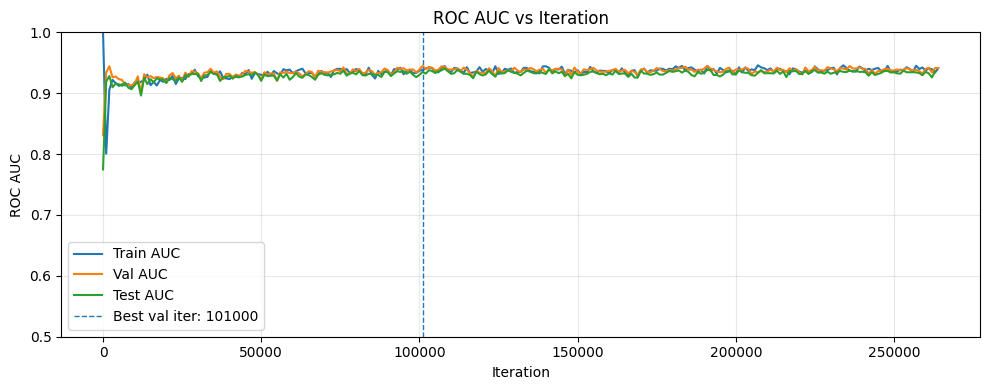

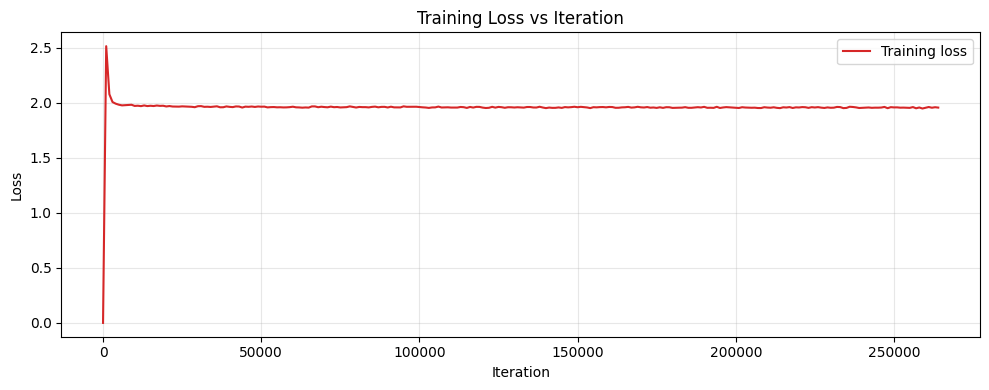

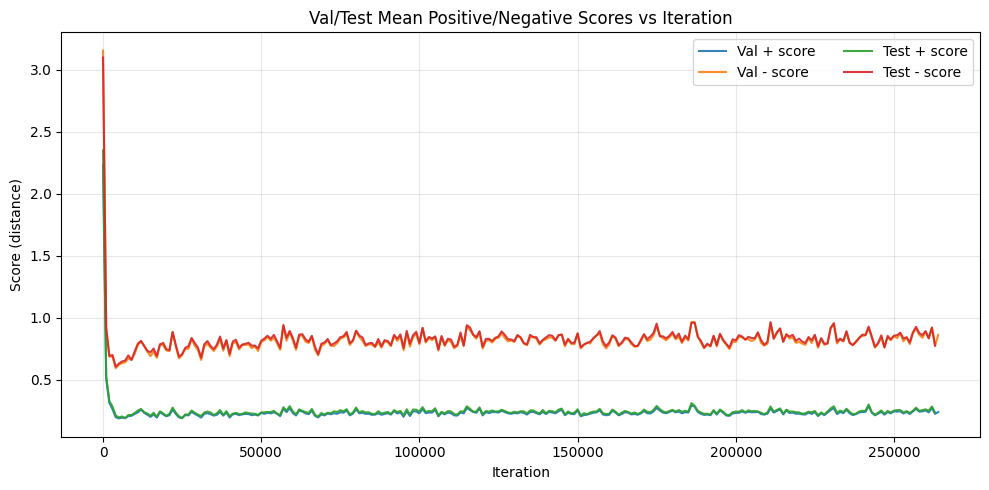

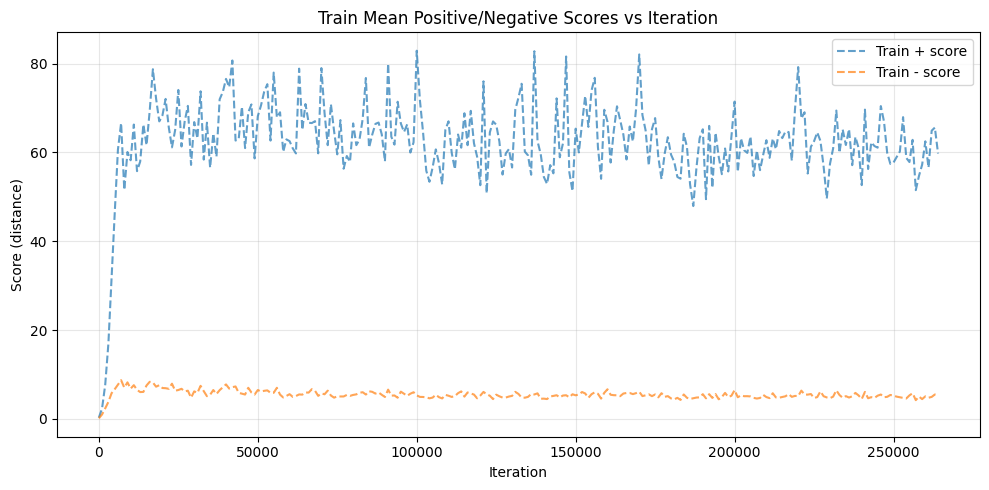

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Expects `model_log` to be set in a previous cell.
log_path = Path("nn_models/sc05/all_feat/model_data/log.txt")
if not log_path.exists():
    raise FileNotFoundError(f"Log file not found: {log_path}")

patterns = {
    "iteration": re.compile(r"^(\d+) training iterations finished"),
    "training_loss": re.compile(r"^\s*training_loss:\s*([0-9eE+\-.]+)"),
    "train_auc": re.compile(r"^Training ROC AUC:\s*([0-9eE+\-.]+)"),
    "val_auc": re.compile(r"^Iteration\s+\d+\s+validation roc auc:\s*([0-9eE+\-.]+)"),
    "test_auc": re.compile(r"^Iteration\s+\d+\s+test roc auc:\s*([0-9eE+\-.]+)"),
    "train_pos_score": re.compile(r"^Mean training positive score:\s*([0-9eE+\-.]+)"),
    "train_neg_score": re.compile(r"^Mean training negative score:\s*([0-9eE+\-.]+)"),
    "val_pos_score": re.compile(r"^Mean validation positive score:\s*([0-9eE+\-.]+)"),
    "val_neg_score": re.compile(r"^Mean validation negative score:\s*([0-9eE+\-.]+)"),
    "test_pos_score": re.compile(r"^Mean test positive score:\s*([0-9eE+\-.]+)"),
    "test_neg_score": re.compile(r"^Mean test negative score:\s*([0-9eE+\-.]+)"),
}

rows = []
current = None
with log_path.open("r", encoding="utf-8", errors="replace") as f:
    for raw in f:
        line = raw.strip()

        m_iter = patterns["iteration"].search(line)
        if m_iter:
            if current and "iteration" in current:
                rows.append(current)
            current = {"iteration": int(m_iter.group(1))}
            continue

        if current is None:
            continue

        for key, pat in patterns.items():
            if key == "iteration":
                continue
            m = pat.search(line)
            if m:
                current[key] = float(m.group(1))
                break

if current and "iteration" in current:
    rows.append(current)

if not rows:
    raise RuntimeError("No training checkpoints parsed from log.")

# Keep only valid checkpoint rows and de-duplicate repeated runs by latest entry.
df = pd.DataFrame(rows)
df = df[df["iteration"].notna()].copy()
df = df.sort_values("iteration").drop_duplicates(subset=["iteration"], keep="last")
df = df.reset_index(drop=True)

if not df["iteration"].is_monotonic_increasing:
    raise RuntimeError("Parsed iterations are not monotonic after sorting.")

print(f"Parsed checkpoints: {len(df)}")

has_val = df["val_auc"].notna().any() if "val_auc" in df.columns else False
has_test = df["test_auc"].notna().any() if "test_auc" in df.columns else False

if has_val:
    best_val_idx = df["val_auc"].idxmax()
    best_val_iter = int(df.loc[best_val_idx, "iteration"])
    best_val_auc = float(df.loc[best_val_idx, "val_auc"])
    print(f"Best val AUC: {best_val_auc:.6f} @ iter {best_val_iter}")
else:
    best_val_iter = None
    print("Best val AUC: N/A")

if has_test:
    best_test_idx = df["test_auc"].idxmax()
    best_test_iter = int(df.loc[best_test_idx, "iteration"])
    best_test_auc = float(df.loc[best_test_idx, "test_auc"])
    print(f"Best test AUC: {best_test_auc:.6f} @ iter {best_test_iter}")
else:
    print("Best test AUC: N/A")

latest = df.iloc[-1]
print(
    "Latest checkpoint:",
    {
        "iteration": int(latest["iteration"]),
        "train_auc": None if pd.isna(latest.get("train_auc", np.nan)) else float(latest["train_auc"]),
        "val_auc": None if pd.isna(latest.get("val_auc", np.nan)) else float(latest["val_auc"]),
        "test_auc": None if pd.isna(latest.get("test_auc", np.nan)) else float(latest["test_auc"]),
        "training_loss": None if pd.isna(latest.get("training_loss", np.nan)) else float(latest["training_loss"]),
    },
)

display(df.head(3))
display(df.tail(3))

# -------------------------
# Figure 1: AUC progression
# -------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for col, label in [("train_auc", "Train AUC"), ("val_auc", "Val AUC"), ("test_auc", "Test AUC")]:
    if col in df.columns and df[col].notna().any():
        ax.plot(df["iteration"], df[col], label=label)

if best_val_iter is not None:
    ax.axvline(best_val_iter, linestyle="--", linewidth=1, label=f"Best val iter: {best_val_iter}")

ax.set_title("ROC AUC vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("ROC AUC")
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 2: Training objective
# ----------------------------
if "training_loss" in df.columns and df["training_loss"].notna().any():
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.plot(df["iteration"], df["training_loss"], color="tab:red", label="Training loss")
    ax.set_title("Training Loss vs Iteration")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------
# Figure 3a: Validation/Test Positive/Negative scores
# ---------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
val_test_scores = [
    ("val_pos_score", "Val + score", "tab:blue", "-"),
    ("val_neg_score", "Val - score", "tab:orange", "-"),
    ("test_pos_score", "Test + score", "tab:green", "-"),
    ("test_neg_score", "Test - score", "tab:red", "-"),
]
for col, label, color, ls in val_test_scores:
    if col in df.columns and df[col].notna().any():
        ax.plot(df["iteration"], df[col], label=label, color=color, linestyle=ls, alpha=0.9)
ax.set_title("Val/Test Mean Positive/Negative Scores vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Score (distance)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", ncol=2)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# Figure 3b: Train Positive/Negative scores only
# ------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
train_scores = [
    ("train_pos_score", "Train + score", "tab:blue", "--"),
    ("train_neg_score", "Train - score", "tab:orange", "--"),
]
for col, label, color, ls in train_scores:
    if col in df.columns and df[col].notna().any():
        ax.plot(df["iteration"], df[col], label=label, color=color, linestyle=ls, alpha=0.7)
ax.set_title("Train Mean Positive/Negative Scores vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Score (distance)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [3]:
import re
from pathlib import Path
import pandas as pd

# Uses the same variable you've already set:
# model_log = "nn_models/sc05/all_feat/model_data/log.txt"

def parse_auc_checkpoints(log_path):
    pat_iter = re.compile(r"^(\d+) training iterations finished")
    pat_val = re.compile(r"^Iteration\s+\d+\s+validation roc auc:\s*([0-9eE+\-.]+)")
    pat_test = re.compile(r"^Iteration\s+\d+\s+test roc auc:\s*([0-9eE+\-.]+)")
    pat_loss = re.compile(r"^\s*training_loss:\s*([0-9eE+\-.]+)")

    rows = []
    cur = None

    with Path(log_path).open("r", encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.strip()

            m = pat_iter.search(line)
            if m:
                if cur and "iteration" in cur:
                    rows.append(cur)
                cur = {"iteration": int(m.group(1))}
                continue

            if cur is None:
                continue

            m = pat_val.search(line)
            if m:
                cur["val_auc"] = float(m.group(1))
                continue

            m = pat_test.search(line)
            if m:
                cur["test_auc"] = float(m.group(1))
                continue

            m = pat_loss.search(line)
            if m:
                cur["training_loss"] = float(m.group(1))
                continue

    if cur and "iteration" in cur:
        rows.append(cur)

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No checkpoints parsed.")
    df = df.sort_values("iteration").drop_duplicates("iteration", keep="last").reset_index(drop=True)
    return df


def recommend_early_stop(df, metric="val_auc", min_delta=0.002, patience_evals=12):
    """
    Early stop when metric fails to improve by at least `min_delta`
    for `patience_evals` consecutive evaluation checkpoints.
    """
    if metric not in df.columns or df[metric].notna().sum() == 0:
        raise ValueError(f"No usable {metric} found.")

    valid = df[["iteration", metric]].dropna().reset_index(drop=True)

    best = float("-inf")
    best_iter = None
    no_improve = 0
    stop_iter = None

    for _, row in valid.iterrows():
        it = int(row["iteration"])
        val = float(row[metric])

        if val > best + min_delta:
            best = val
            best_iter = it
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience_evals:
                stop_iter = it
                break

    out = {
        "best_iter": best_iter,
        "best_val": best,
        "stop_iter_recommendation": stop_iter,
        "used_metric": metric,
        "min_delta": min_delta,
        "patience_evals": patience_evals,
    }
    return out, valid


# ---- run ----
df = parse_auc_checkpoints(log_path)
result, valid = recommend_early_stop(
    df,
    metric="val_auc",     # use validation for model selection
    min_delta=0.002,      # meaningful AUC gain threshold
    patience_evals=12     # 12 evals ~= 12k iterations (if eval every 1000)
)

print(f"Parsed checkpoints: {len(df)}")
print(f"Best val_auc: {result['best_val']:.6f} at iter {result['best_iter']}")
if result["stop_iter_recommendation"] is None:
    print("No early-stop trigger yet under current settings.")
else:
    print(f"Recommended early stop by iter: {result['stop_iter_recommendation']}")

# Optional quick look at latest points
display(df.tail(10))

Parsed checkpoints: 266
Best val_auc: 0.944268 at iter 2000
Recommended early stop by iter: 14000


,iteration,training_loss,val_auc,test_auc
256,256000,1.960393,0.937453,0.934500
257,257000,1.949451,0.938379,0.934205
258,258000,1.956750,0.936352,0.933150
259,259000,1.947384,0.931962,0.929415
260,260000,1.953742,0.939733,0.935235
261,261000,1.960993,0.941855,0.932564
262,262000,1.954472,0.934013,0.925866
263,263000,1.959019,0.941308,0.936266
264,264000,1.955731,0.941449,0.933008
265,265000,1.953727,0.938943,0.933893


In [2]:
# ---- Compare performance of new vs old model ----
import numpy as np
from sklearn.metrics import roc_auc_score
import os

# add source folder to python path
repo_root = !git rev-parse --show-toplevel
repo_root = repo_root[0]
source_dir = os.path.join(repo_root, "masif", "source")
import sys
sys.path.append(source_dir)

# Work in masif_ppi_search directory
os.chdir(os.path.join(repo_root, "masif", "data", "masif_ppi_search"))

from masif_modules.MaSIF_ppi_search import MaSIF_ppi_search
from masif_modules.train_ppi_search import compute_val_test_desc
from default_config.masif_opts import masif_opts

# ---- config ----
cache_dir = "nn_models/sc05/cache/"
feat_mask = [1.0, 1.0, 1.0, 1.0, 1.0]
model_dirs = {
    "new": "nn_models/sc05/all_feat/model_data/",
    "old": "nn_models/sc05/all_feat/archive/model_data/",
}

def mask_input_feat(input_feat, mask):
    mymask = np.where(np.array(mask) == 0.0)[0]
    return np.delete(input_feat, mymask, axis=2)

def eval_model(model_dir):
    # load cache arrays
    binder_rho = np.load(cache_dir + "/binder_rho_wrt_center.npy")
    binder_theta = np.load(cache_dir + "/binder_theta_wrt_center.npy")
    binder_feat = mask_input_feat(np.load(cache_dir + "/binder_input_feat.npy"), feat_mask)
    binder_mask = np.load(cache_dir + "/binder_mask.npy")

    pos_rho = np.load(cache_dir + "/pos_rho_wrt_center.npy")
    pos_theta = np.load(cache_dir + "/pos_theta_wrt_center.npy")
    pos_feat = mask_input_feat(np.load(cache_dir + "/pos_input_feat.npy"), feat_mask)
    pos_mask = np.load(cache_dir + "/pos_mask.npy")
    pos_test_idx = np.load(cache_dir + "/pos_test_idx.npy").astype(int)

    neg_rho = np.load(cache_dir + "/neg_rho_wrt_center.npy")
    neg_theta = np.load(cache_dir + "/neg_theta_wrt_center.npy")
    neg_feat = mask_input_feat(np.load(cache_dir + "/neg_input_feat.npy"), feat_mask)
    neg_mask = np.load(cache_dir + "/neg_mask.npy")
    neg_test_idx = np.load(cache_dir + "/neg_test_idx.npy").astype(int)

    # build net + restore checkpoint
    p = masif_opts["ppi_search"]
    net = MaSIF_ppi_search(
        p["max_distance"], n_thetas=16, n_rhos=5, n_rotations=16,
        idx_gpu="/gpu:0", feat_mask=feat_mask
    )
    net.saver.restore(net.session, model_dir + "model")

    # descriptors on same test split
    pos_desc = compute_val_test_desc(net, pos_test_idx, pos_rho, pos_theta, pos_feat, pos_mask, batch_size=1000)
    binder_desc = compute_val_test_desc(net, pos_test_idx, binder_rho, binder_theta, binder_feat, binder_mask, batch_size=1000, flip=True)
    neg_desc = compute_val_test_desc(net, neg_test_idx, neg_rho, neg_theta, neg_feat, neg_mask, batch_size=1000)

    # align negative count with binder_desc count (same as training helper behavior)
    n = min(len(neg_desc), len(binder_desc))
    rng = np.random.RandomState(0)
    neg_desc = neg_desc[rng.choice(len(neg_desc), size=n, replace=False)]
    neg_desc_2 = binder_desc[rng.choice(len(binder_desc), size=n, replace=False)]

    pos_dists = np.sqrt(np.sum((pos_desc - binder_desc) ** 2, axis=1))
    neg_dists = np.sqrt(np.sum((neg_desc - neg_desc_2) ** 2, axis=1))

    y_true = np.concatenate([np.ones(len(pos_dists)), np.zeros(len(neg_dists))])
    y_score = 1.0 / np.concatenate([pos_dists, neg_dists])  # smaller dist = more positive
    auc = roc_auc_score(y_true, y_score)

    return {
        "auc": float(auc),
        "mean_pos_dist": float(np.mean(pos_dists)),
        "mean_neg_dist": float(np.mean(neg_dists)),
        "n_pos": int(len(pos_dists)),
        "n_neg": int(len(neg_dists)),
    }

results = {name: eval_model(path) for name, path in model_dirs.items()}
print(results)

/usr/local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:523: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/usr/local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:524: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/usr/local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:525: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/usr/local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:526: FutureWarning: Passing (type, 1) or 

(80, 2)
Instructions for updating:
keep_dims is deprecated, use keepdims instead


/usr/local/lib/python3.6/site-packages/tensorflow/python/ops/gradients_impl.py:112: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "


Total number parameters: 66080
INFO:tensorflow:Restoring parameters from nn_models/sc05/all_feat/model_data/model
(80, 2)


/usr/local/lib/python3.6/site-packages/tensorflow/python/ops/gradients_impl.py:112: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "


Total number parameters: 66080
INFO:tensorflow:Restoring parameters from nn_models/sc05/all_feat/archive/model_data/model
{'new': {'auc': 0.9353191303850841, 'mean_pos_dist': 0.27939820289611816, 'mean_neg_dist': 0.9187645316123962, 'n_pos': 17951, 'n_neg': 17951}, 'old': {'auc': 0.9836454268527729, 'mean_pos_dist': 1.8461123704910278, 'mean_neg_dist': 3.830016851425171, 'n_pos': 17951, 'n_neg': 17951}}


In [3]:
results

{'new': {'auc': 0.9353191303850841,
  'mean_pos_dist': 0.27939820289611816,
  'mean_neg_dist': 0.9187645316123962,
  'n_pos': 17951,
  'n_neg': 17951},
 'old': {'auc': 0.9836454268527729,
  'mean_pos_dist': 1.8461123704910278,
  'mean_neg_dist': 3.830016851425171,
  'n_pos': 17951,
  'n_neg': 17951}}

### Step 1.4: Generate Descriptors with New Model

Run inference with the newly trained model:
```bash
sbatch compute_descriptors.slurm
```

**What this does:**
- Loads the trained MaSIF-ppi-search weights
- Runs inference on all proteins
- Generates 80D descriptors for each surface vertex

**Expected output per protein complex:**
```
descriptors/sc05/all_feat/PDBID_CHAIN1_CHAIN2/
├── p1_desc_straight.npy    # Chain 1 descriptors (normal)
├── p1_desc_flipped.npy      # Chain 1 descriptors (flipped for complementarity)
├── p2_desc_straight.npy     # Chain 2 descriptors (normal)
└── p2_desc_flipped.npy      # Chain 2 descriptors (flipped)
```

In [ ]:
!sbatch compute_descriptors.slurm

In [ ]:
# Check the descriptors
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path(".")  # or Path("masif/data/masif_ppi_search") if running from repo root
desc_dir = DATA_DIR / "descriptors/sc05/all_feat"


def load_descriptors(model_id):
    desc_fn = desc_dir / f"{model_id}/p1_desc_straight.npy"
    return np.load(desc_fn)

# Example: load descriptors for a specific model
model_id = "1CQI_A_B"
descriptors = load_descriptors(model_id)
print(descriptors.shape)  # Should print (n_vertices, 80)
